In [2]:
# Базовые библиотеки
import os
import math
import time
import random
from typing import Tuple, Dict, List

import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

# Датасеты / трансформации
import torchvision
from torchvision import transforms

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu


In [3]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Детеминизм (может замедлить)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = False   # переключите на True для частичного датасета и более быстрого обучения
DATA_DIR = "./data"

BATCH_SIZE = 128
EPOCHS = 12 if FAST_MODE else 50

Device: cpu


## Загрузка данных: STL10

In [4]:
# STL-10 mean/std (часто используемые значения)
STL10_MEAN = (0.4467, 0.4398, 0.4066)
STL10_STD  = (0.2603, 0.2566, 0.2713)

def load_stl10(data_dir: str = DATA_DIR):
    tf_train = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD),
    ])
    tf_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD),
    ])

    # STL10 имеет разные наборы: train (5000 изображений) и test (8000 изображений)
    # Также есть дополнительный неразмеченный набор, но здесь используем размеченные
    ds_train_full = torchvision.datasets.STL10(root=data_dir, split='train', download=True, transform=tf_train)
    ds_test = torchvision.datasets.STL10(root=data_dir, split='test', download=True, transform=tf_test)

    return ds_train_full, ds_test

ds_train_full, ds_test = load_stl10()
class_names = ds_train_full.classes
print("Train full:", len(ds_train_full))
print("Test:", len(ds_test))
print("Classes:", class_names)

Train full: 5000
Test: 8000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [5]:
def make_loaders(
    ds_train_full,
    ds_test,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    # train/val split
    n_total = len(ds_train_full)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val

    ds_train, ds_val = random_split(
        ds_train_full,
        lengths=[n_train, n_val],
        generator=torch.Generator().manual_seed(seed),
    )

    # FAST_MODE: уменьшаем размер для скорости
    if fast_mode:
        # аккуратно: Subset от Subset (random_split возвращает Subset)
        rng = np.random.RandomState(seed)
        train_idx = rng.choice(len(ds_train), size=min(6000, len(ds_train)), replace=False)
        val_idx = rng.choice(len(ds_val), size=min(1500, len(ds_val)), replace=False)
        test_idx = rng.choice(len(ds_test), size=min(1500, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx)
        ds_val = Subset(ds_val, val_idx)
        ds_test_small = Subset(ds_test, test_idx)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=False)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=False)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=False)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders(ds_train_full, ds_test)

batch = next(iter(train_loader))
x, y = batch
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

x: torch.Size([128, 3, 96, 96]) torch.float32
y: torch.Size([128]) torch.int64


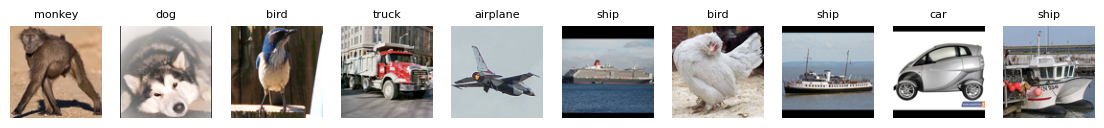

In [9]:
def denorm_stl10(x: torch.Tensor) -> torch.Tensor:
    # x: (C,H,W), нормализованный
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 4))  # Увеличил высоту для STL10 (96x96)
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_stl10(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

# Получаем имена классов
class_names = ds_train_full.classes

# Показываем изображения
show_images(train_loader, n=10)

In [14]:
INPUT_DIM = 96 * 96 * 3
NUM_CLASSES = 10
class SimpleCNN_STL10(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            # Вход: 3x96x96
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 96x96 -> 96x96
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 96x96 -> 48x48

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 48x48 -> 48x48
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 48x48 -> 24x24

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 24x24 -> 24x24
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 24x24 -> 12x12

            nn.Conv2d(128, 256, kernel_size=3, padding=1),# 12x12 -> 12x12
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 12x12 -> 6x6
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 512),  # 256 * 36 = 9216
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x



In [15]:
def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)
cnn = SimpleCNN_STL10(NUM_CLASSES).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN_STL10(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=9216, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=10, bias=True)


In [16]:
# Быстрый sanity-check по shape
with torch.no_grad():
    x0 = torch.randn(2, 3, 96, 96).to(DEVICE)  # STL10: 96x96
    y0 = cnn(x0)
print("Input:", x0.shape, "Output logits:", y0.shape)

Input: torch.Size([2, 3, 96, 96]) Output logits: torch.Size([2, 10])


In [17]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen
def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 50, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history
def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

## Эксперимент C1: CNN без аугментации

In [21]:
# cnn = SimpleCNN_STL10(NUM_CLASSES).to(DEVICE)
# выше создали модель

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3, weight_decay=1e-4)
history = fit(cnn, train_loader, val_loader, optimizer, criterion, epochs=15, verbose=True)


Epoch 01/15 | train loss 0.0802, acc 0.974 | val loss 0.0084, acc 0.997 | 53.3s
Epoch 02/15 | train loss 0.0788, acc 0.973 | val loss 0.0025, acc 1.000 | 43.2s
Epoch 03/15 | train loss 0.0355, acc 0.987 | val loss 0.0050, acc 0.998 | 46.6s
Epoch 04/15 | train loss 0.0607, acc 0.980 | val loss 0.0036, acc 1.000 | 46.6s
Epoch 05/15 | train loss 0.0453, acc 0.983 | val loss 0.0020, acc 1.000 | 155220.8s
Epoch 06/15 | train loss 0.0557, acc 0.981 | val loss 0.0038, acc 1.000 | 91.7s
Epoch 07/15 | train loss 0.0448, acc 0.984 | val loss 0.0091, acc 0.995 | 98.9s
Epoch 08/15 | train loss 0.0566, acc 0.981 | val loss 0.0043, acc 0.998 | 101.4s
Epoch 09/15 | train loss 0.0543, acc 0.982 | val loss 0.0072, acc 0.998 | 97.7s
Epoch 10/15 | train loss 0.0774, acc 0.974 | val loss 0.0276, acc 0.994 | 8494.8s
Epoch 11/15 | train loss 0.0904, acc 0.968 | val loss 0.0054, acc 0.999 | 97.9s
Epoch 12/15 | train loss 0.0513, acc 0.983 | val loss 0.0022, acc 1.000 | 98.5s
Epoch 13/15 | train loss 0.0486, 

In [20]:
plot_history(history, title="Simple CNN")

NameError: name 'history' is not defined

In [ ]:
# Лучшая валидационная точность
best_val_acc_c1 = float(np.nanmax(history["val_acc"]))
results_c1 = [{
    'experiment_id': 'C1',
    'task': 'classification',
    'dataset': 'STL10',
    'seed': RANDOM_STATE,
    'model_summary': f'SimpleCNN_{count_params(cnn)}params',
    'optimizer': 'Adam',
    'lr': 0.001,
    'epochs_trained': EPOCHS,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': None,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'No augmentations'
}]

df = pd.DataFrame(results_c1)
df.to_csv('homeworks/HW10-11/artifacts/runs.csv', index=False)